## Подготовка

In [260]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [261]:
data = pd.read_csv('data/r5_eda.csv')

In [262]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   int64  
 6   total_sulfur_dioxide  6497 non-null   int64  
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(9), int64(3)
memory usage: 609.2 KB


In [263]:
y = data['quality']
X = data.drop('quality', axis=1)

In [264]:
from sklearn.model_selection import train_test_split

In [265]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [266]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5197, 11), (5197,), (1300, 11), (1300,))

In [267]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

## Реализация пользовательских функций

In [268]:
import numpy as np

$ MAE=\frac{1}{m}{\sum_{i=1}^{m}|y_i-\hat{y}_i|} $

In [269]:
def mae_metrick(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

$ MSE=\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2} $

In [270]:
def mse_metrick(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

$ RMSE=\sqrt{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2}} $

In [271]:
def rmse_metrick(y_true, y_pred):
    return np.sqrt(mse_metrick(y_true, y_pred))

$ MAPE=\frac{1}{m}\sum_{i=1}^{m}{|\frac{y_i-\hat{y}_i}{y_i}|} $

In [272]:
def mape_metrick(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

$ R^2=\frac{MSE}{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\bar{y})^2}} $. $\bar{y}$ - среднее значение целевого признака.

In [273]:
def r2_score_metrick(y_true, y_pred):
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    numerator = mse_metrick(y_true, y_pred)
    return numerator / denominator

Вспомогательные

In [274]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt

In [275]:
def sklearn_metrick_printer(y_true, y_pred):
    print(f'MAE: {mean_absolute_error(y_true, y_pred)}')
    print(f'MSE: {mean_squared_error(y_true, y_pred)}')
    print(f'RMSE: {sqrt(mean_squared_error(y_true, y_pred))}')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred)}')
    print(f'R^2: {r2_score(y_true, y_pred)}')

In [276]:
def metrick_printer(y_true, y_pred):
    print(f'MAE: {mae_metrick(y_true, y_pred)}')
    print(f'MSE: {mse_metrick(y_true, y_pred)}')
    print(f'RMSE: {rmse_metrick(y_true, y_pred)}')
    print(f'MAPE: {mape_metrick(y_true, y_pred)}')
    print(f'R^2: {r2_score_metrick(y_true, y_pred)}')

In [277]:
def return_metricks(y_true, y_pred):
    return [mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred), sqrt(mean_squared_error(
        y_true, y_pred)), mean_absolute_percentage_error(y_true, y_pred), r2_score(y_true, y_pred)]

## Простая линейная регрессия

In [278]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)

### Метрики

In [279]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5795882666828077
MSE: 0.5649138797917962
RMSE: 0.7516075304251523
MAPE: 0.10397954491541718
R^2: 0.2694395311578067


In [280]:
metrick_printer(y_test, y_pred)

MAE: 0.5795882666828077
MSE: 0.5649138797917962
RMSE: 0.7516075304251523
MAPE: 0.10397954491541718
R^2: 0.0005619695914170717


In [281]:
len(lr.coef_)
lr.coef_

array([ 6.87999173e-02, -1.32449367e+00, -8.37964612e-02,  4.27933016e-02,
       -4.05509233e-01,  5.97225440e-03, -2.44835038e-03, -5.66853173e+01,
        4.65220621e-01,  7.72814616e-01,  2.65136578e-01])

## Линейная регрессия с L1-регуляризацией

In [282]:
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
y_pred = lasso.predict(X_test)

### Метрики

In [283]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.6808404372645149
MSE: 0.7652215261956441
RMSE: 0.874769413157344
MAPE: 0.12279192214576645
R^2: 0.010396775608226161


In [284]:
metrick_printer(y_test, y_pred)

MAE: 0.6808404372645149
MSE: 0.7652215261956441
RMSE: 0.874769413157344
MAPE: 0.12279192214576645
R^2: 0.0007612332495321336


In [285]:
lasso.coef_

array([-0.        , -0.        ,  0.        , -0.        , -0.        ,
        0.00503749, -0.00164888, -0.        ,  0.        ,  0.        ,
        0.        ])

### Подбор гиперпараметров

In [286]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
import numpy as np
import optuna

GridSearchCV

In [287]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10]}

In [288]:
grid = GridSearchCV(Lasso(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10]},
             scoring='r2')

In [289]:
print("Best alpha:", grid.best_params_['alpha'])
print("Best R^2:", grid.best_score_)

Best alpha: 0.001
Best R^2: 0.2895797107077399


RandomizedSearchCV

In [290]:
param_dist = {'alpha': np.logspace(-4, 1, 100)}

In [291]:
random_search = RandomizedSearchCV(
    Lasso(), param_dist, n_iter=20, cv=5, scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Lasso(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6.42807312e-04, 7.22080...
       6.89261210e-01, 7.74263683e-01, 8.69749003e-01, 9.77009957e-01,
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01])},
                   random_state=42, scoring='r2')

In [292]:
print("Best alpha:", random_search.best_params_['alpha'])
print("Best R^2:", random_search.best_score_)

Best alpha: 0.0001
Best R^2: 0.2902458627873105


Фреймворк Optuna

In [293]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    model = Lasso(alpha=alpha)
    score = cross_val_score(model, X_train, y_train, scoring='r2', cv=5).mean()
    return score

In [294]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2025-04-25 09:54:19,922] A new study created in memory with name: no-name-6ae2515e-8411-4197-a97d-3a4e79754f2c
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\1532896469.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
[I 2025-04-25 09:54:19,939] Trial 0 finished with value: 0.28931909573753983 and parameters: {'alpha': 0.0019183464813914092}. Best is trial 0 with value: 0.28931909573753983.
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\1532896469.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
[I 2025-04-25 09:54:19,953] Trial 1 finished with valu

In [295]:
print("Best alpha:", study.best_params['alpha'])
print("Best R^2:", study.best_value)

Best alpha: 0.00010225760498705478
Best R^2: 0.29024492711259847


Сравнение гиперпараметров

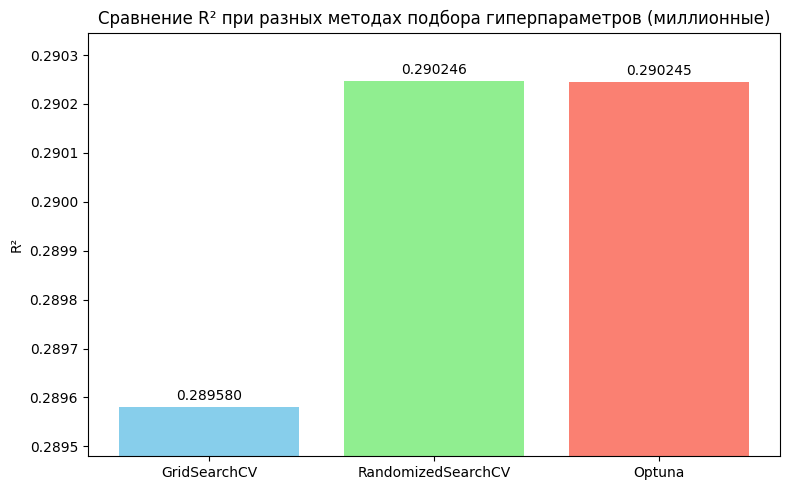

In [296]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [297]:
lasso_best = Lasso(alpha=0.0001).fit(X_train, y_train)
y_pred_new = lasso_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [298]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5814854266987467
MSE: 0.5661319508629785
RMSE: 0.7524174046783996
MAPE: 0.10426284888490277
R^2: 0.2678642918077415


In [299]:
lasso_best.coef_

array([ 0.00992874, -1.4496649 , -0.08732739,  0.0213146 , -0.6143783 ,
        0.0060148 , -0.00220707, -0.        ,  0.18157792,  0.63605602,
        0.3317463 ])

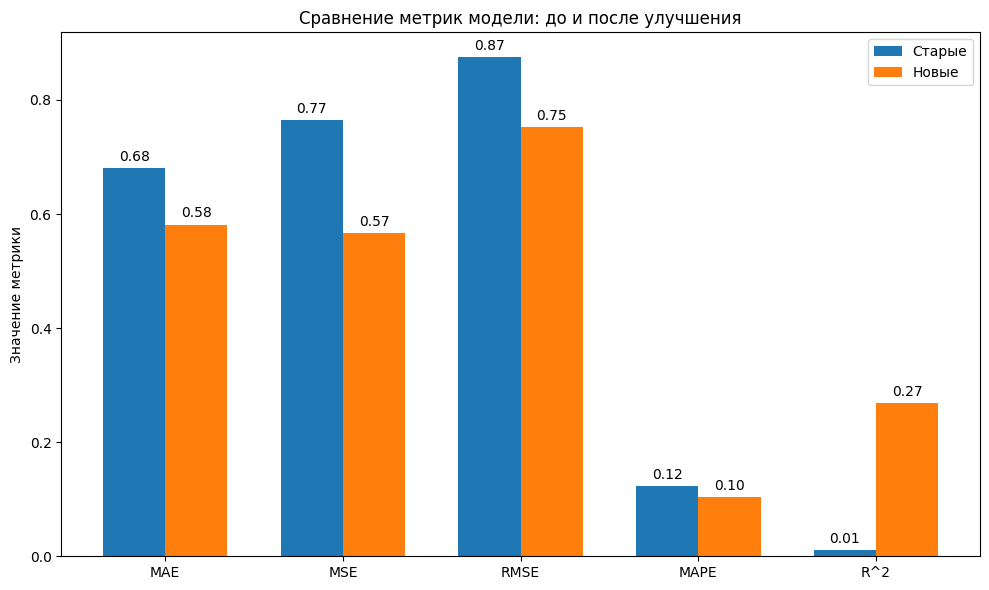

In [300]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_12104\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

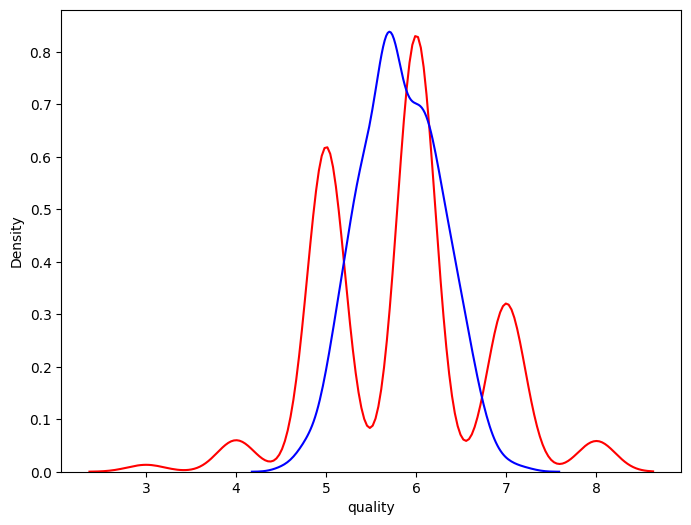

In [301]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Линейная регрессия с L2-регуляризацией

In [302]:
ridge = Ridge(alpha=0.5).fit(X_train, y_train)
y_pred = ridge.predict(X_test)

### Метрики

In [303]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5813958670785434
MSE: 0.5660818355412612
RMSE: 0.752384101068903
MAPE: 0.10424766243886499
R^2: 0.26792910216953236


In [304]:
metrick_printer(y_test, y_pred)

MAE: 0.5813958670785434
MSE: 0.5660818355412612
RMSE: 0.752384101068903
MAPE: 0.10424766243886499
R^2: 0.0005631314598695906


In [305]:
len(ridge.coef_)
ridge.coef_

array([ 0.01076351, -1.44721263, -0.0913243 ,  0.02145942, -0.65760746,
        0.00601977, -0.00220658, -0.34157288,  0.1860645 ,  0.6411113 ,
        0.33113664])

### Подбор гиперпараметров

GridSearchCV

In [306]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100]}

In [307]:
grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100]},
             scoring='r2')

In [308]:
print("Best alpha:", grid.best_params_['alpha'])
print("Best R^2:", grid.best_score_)

Best alpha: 0.001
Best R^2: 0.2918941215957764


RandomizedSearchCV

In [309]:
param_dist = {'alpha': np.logspace(-4, 2, 100)}

In [310]:
random_search = RandomizedSearchCV(Ridge(), param_distributions=param_dist, n_iter=20, cv=5,
                                   scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226...
       4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02])},
                   random_state=42, scoring='r2')

In [311]:
print("Best alpha:", random_search.best_params_['alpha'])
print("Best R^2:", random_search.best_score_)

Best alpha: 0.0012328467394420659
Best R^2: 0.2918805218032101


Фреймворк Optuna

In [312]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
    model = Ridge(alpha=alpha)
    score = cross_val_score(model, X_train, y_train, scoring='r2', cv=5).mean()
    return score

In [313]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2025-04-25 09:54:21,254] A new study created in memory with name: no-name-57de6d03-b34d-4e9b-b26f-30c12eaf3618
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\1837225706.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
[I 2025-04-25 09:54:21,271] Trial 0 finished with value: 0.2896440162407915 and parameters: {'alpha': 7.497961822027594}. Best is trial 0 with value: 0.2896440162407915.
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\1837225706.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
[I 2025-04-25 09:54:21,289] Trial 1 finished with value: 0

In [314]:
print("Best alpha:", study.best_params['alpha'])
print("Best R^2:", study.best_value)

Best alpha: 0.0008692093083583274
Best R^2: 0.29189585453406197


Сравнение гиперпараметров

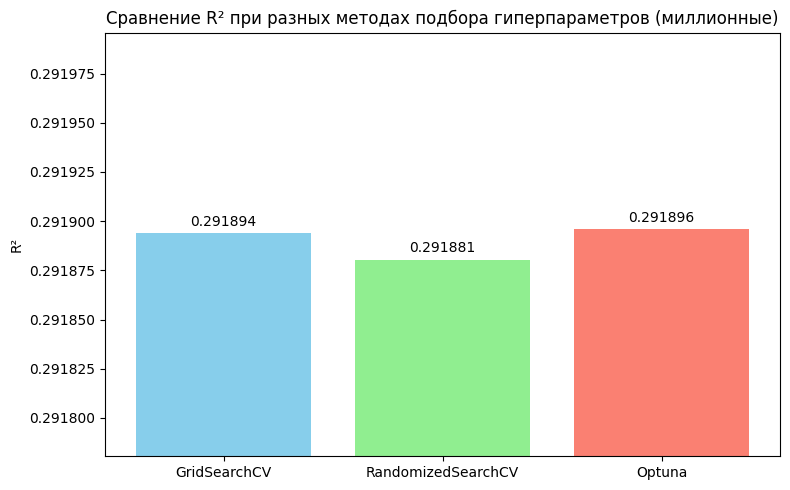

In [315]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [316]:
ridge_best = Ridge(alpha=0.0001).fit(X_train, y_train)
y_pred_new = ridge_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [317]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5796203586931148
MSE: 0.5648977995868598
RMSE: 0.7515968331405207
MAPE: 0.10398357934622653
R^2: 0.2694603264727701


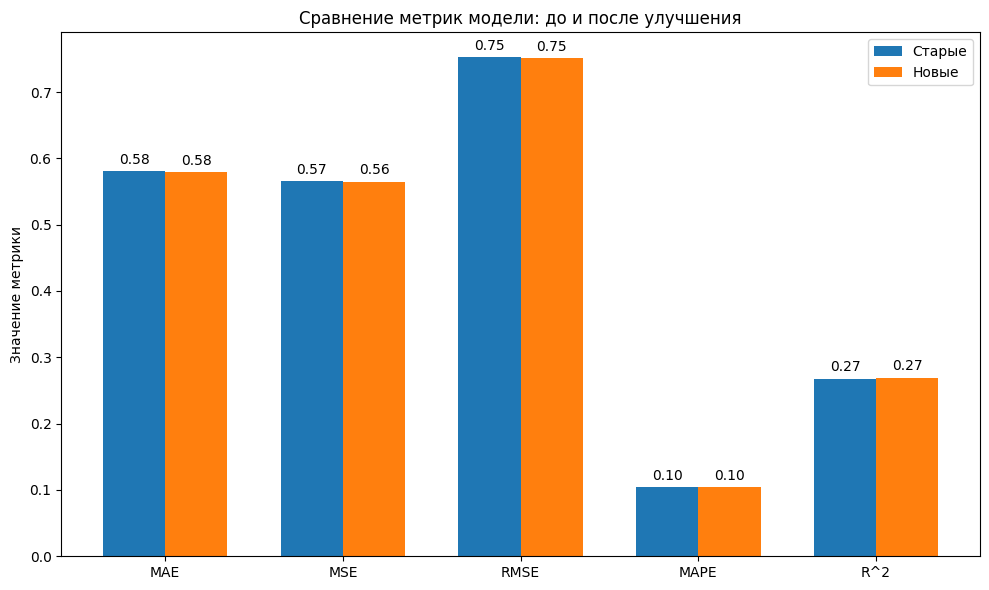

In [318]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_12104\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

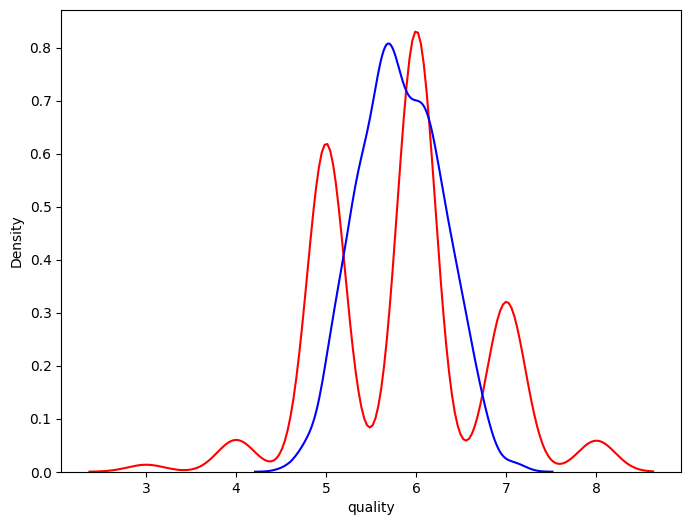

In [319]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Линейная регрессия с двумя регуляризаторами

In [320]:
base_elastic_model = ElasticNet(max_iter=100000, alpha=1.0, l1_ratio=0.5)
base_elastic_model.fit(X_train, y_train)
y_pred = base_elastic_model.predict(X_test)

### Метрики

In [321]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.6808617809855575
MSE: 0.7652338013928903
RMSE: 0.8747764293766095
MAPE: 0.1227957083482085
R^2: 0.010380901022424616


In [322]:
metrick_printer(y_test, y_pred)

MAE: 0.6808617809855575
MSE: 0.7652338013928903
RMSE: 0.8747764293766095
MAPE: 0.1227957083482085
R^2: 0.0007612454607519812


In [323]:
len(base_elastic_model.coef_)
base_elastic_model.coef_

array([-0.        , -0.        ,  0.        , -0.        , -0.        ,
        0.00501995, -0.00164464, -0.        ,  0.        ,  0.        ,
        0.        ])

### Подбор гиперпараметров

GridSearchCV

In [324]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

In [325]:
grid = GridSearchCV(
    ElasticNet(max_iter=100000),
    param_grid,
    scoring='r2',
    cv=5
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=100000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='r2')

In [326]:
print("Best params:", grid.best_params_)
print("Best R^2:", grid.best_score_)

Best params: {'alpha': 0.001, 'l1_ratio': 0.1}
Best R^2: 0.2899924552267702


RandomizedSearchCV

In [327]:
param_dist = {
    'alpha': np.logspace(-4, 1, 100),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}

In [328]:
random_search = RandomizedSearchCV(
    ElasticNet(max_iter=100000),
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=5,
    random_state=42
)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=ElasticNet(max_iter=100000), n_iter=30,
                   param_distributions={'alpha': array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6....
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01]),
                                        'l1_ratio': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
                   random_state=42, scoring='r2')

In [329]:
print("Best params:", random_search.best_params_)
print("Best R^2:", random_search.best_score_)

Best params: {'l1_ratio': np.float64(0.1), 'alpha': np.float64(0.00025353644939701115)}
Best R^2: 0.29026107644450977


Фреймворк Optuna

In [330]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
    return score

In [331]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

[I 2025-04-25 09:54:23,001] A new study created in memory with name: no-name-5e7de2e3-49ba-407a-af21-4a71ef029ed1
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\4049124632.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\4049124632.py:3: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
[I 2025-04-25 09:54:23,026] Trial 0 finished with value: 0.14436484492565366 and parameters: {'alpha': 1.1316090139822184, 'l1_ratio': 0.12630275581072692}. Best is trial 0 with value: 0.14436484492565366.
C:\Users\andre\AppData\Local\Temp\ipykern

In [332]:
print("Best params:", study.best_params)
print("Best R^2:", study.best_value)

Best params: {'alpha': 0.00010679523695738828, 'l1_ratio': 0.37427710109446993}
Best R^2: 0.2902672618273828


Сравнение гиперпараметров

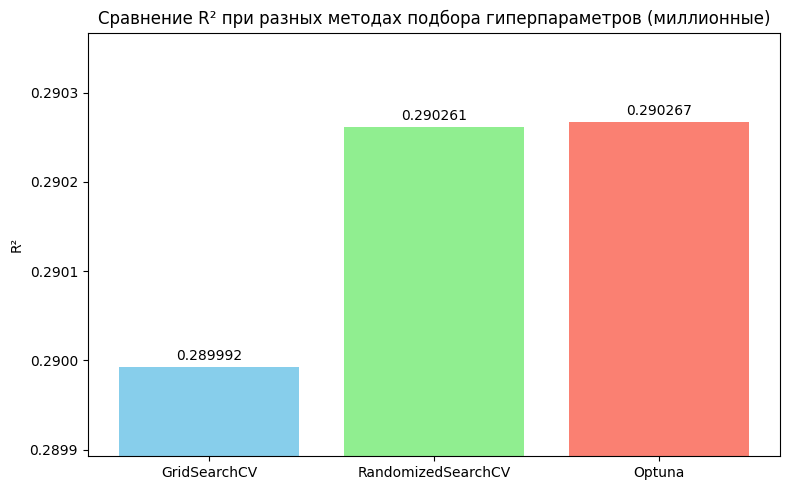

In [333]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [334]:
base_elastic_model = ElasticNet(max_iter=100000, alpha=0.000253, l1_ratio=0.1)
base_elastic_model.fit(X_train, y_train)
y_pred_new = base_elastic_model.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [335]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5815639347704762
MSE: 0.5661722636228618
RMSE: 0.7524441930288662
MAPE: 0.1042763090035055
R^2: 0.2678121583590617


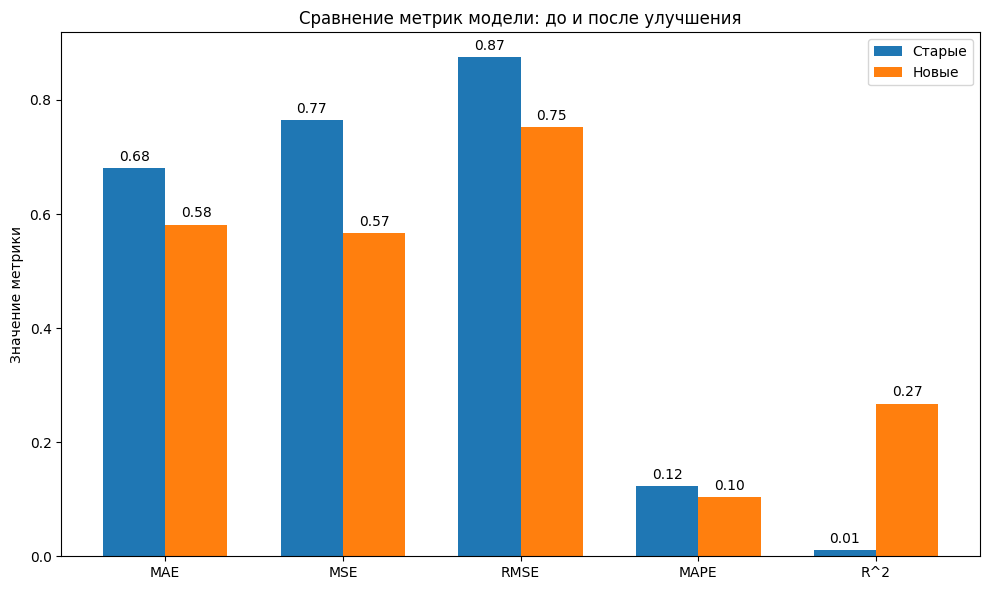

In [336]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_12104\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

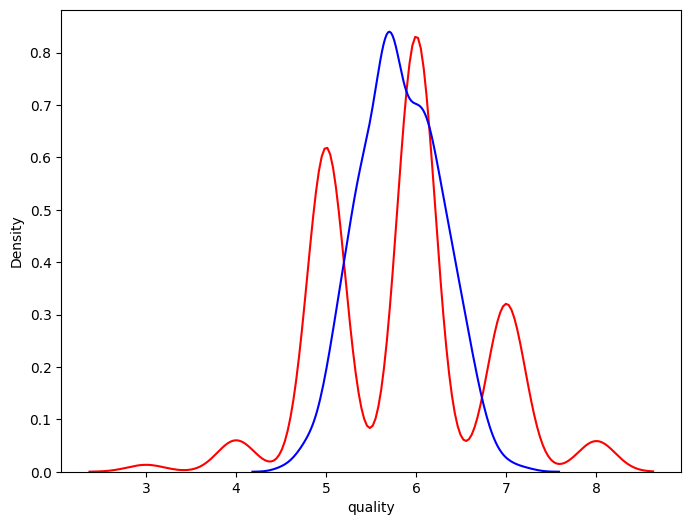

In [337]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Полиномиальная регрессия

In [338]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [339]:
polynomial_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

In [340]:
polynomial_model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()), ('reg', LinearRegression())])

In [341]:
y_pred = polynomial_model.predict(X_test)

### Метрики

In [342]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5611373570351738
MSE: 0.5325042216495922
RMSE: 0.7297288685872255
MAPE: 0.10087977732538973
R^2: 0.31135249505260465


In [343]:
metrick_printer(y_test, y_pred)

MAE: 0.5611373570351738
MSE: 0.5325042216495922
RMSE: 0.7297288685872255
MAPE: 0.10087977732538973
R^2: 0.0005297288499595349


In [344]:
polynomial_model.named_steps['reg'].coef_

array([-1.85872610e+01, -6.51061878e+00,  5.62617044e+01, -6.32742470e+01,
       -4.25687169e+01,  7.17180908e+00,  7.33523247e+01, -3.78215024e+00,
        6.23627112e+01, -1.91919956e+01,  1.54754279e+01, -7.40129989e-01,
        3.85048246e-02,  7.74992453e-01, -4.67938896e-01, -5.82172570e-01,
        1.68269680e-01,  7.44640829e-02,  1.81843802e+01,  1.27140205e+00,
        3.28226767e-02, -1.07474030e-01,  4.95819450e-02,  3.09516850e-02,
       -1.97433735e-01,  1.10833480e-01,  1.88947061e-03,  5.67360951e-02,
        5.48993192e+00,  1.95469226e-01,  1.03050303e-02,  5.32963886e-01,
       -1.27165738e-01,  2.37190568e-01,  1.35444306e-01,  1.05202074e-01,
        9.96699254e-03, -5.78948058e+01,  1.16495859e+00, -7.63901658e-02,
       -3.18351188e-01, -7.54121380e-01, -2.37121931e-01, -9.68459198e-02,
        5.31126317e-01,  6.42458308e+01,  3.81053402e-02, -2.64698873e-01,
        6.63358285e-01, -5.85874377e-02,  2.47083690e-02, -6.87006994e-02,
        4.46325966e+01, -

### Подбор гиперпараметров

GridSearchCV

In [345]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', ElasticNet(max_iter=100000))
])

In [346]:
param_grid = {
    'poly__degree': [2, 3],
    'reg__alpha': [0.001, 0.01, 0.1, 1],
    'reg__l1_ratio': [0.2, 0.5, 0.8]
}

In [347]:
# grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
# grid.fit(X_train, y_train)

In [348]:
# print("Best params:", grid.best_params_)
# print("Best R^2:", grid.best_score_)

RandomizedSearchCV

In [349]:
param_dist = {
    'poly__degree': [2, 3],
    'reg__alpha': np.logspace(-4, 1, 100),
    'reg__l1_ratio': np.linspace(0.1, 0.9, 9)
}

In [350]:
# random_search = RandomizedSearchCV(
#     pipeline, param_distributions=param_dist,
#     n_iter=30, cv=5, scoring='r2', random_state=42
# )
# random_search.fit(X_train, y_train)

In [351]:
# print("Best params:", random_search.best_params_)
# print("Best R^2:", random_search.best_score_)

Фреймворк Optuna

In [352]:
# def objective(trial):
#     degree = trial.suggest_int('degree', 2, 3)
#     alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
#     l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)

#     pipeline = Pipeline([
#         ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
#         ('scaler', StandardScaler()),
#         ('reg', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000))
#     ])

#     score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2').mean()
#     return score

In [353]:
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=40)

In [354]:
# print("Best params:", study.best_params)
# print("Best R^2:", study.best_value)

Сравнение гиперпараметров

In [355]:
# models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

# r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

# fig, ax = plt.subplots(figsize=(8, 5))
# bars = ax.bar(models, r2_scores, color=[
#               'skyblue', 'lightgreen', 'salmon'])

# ax.set_ylabel('R²')
# ax.set_title(
#     'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

# margin = 0.0001
# y_min = min(r2_scores) - margin
# y_max = max(r2_scores) + margin

# ax.set_ylim(y_min, y_max)

# for bar in bars:
#     height = bar.get_height()
#     ax.annotate(f'{height:.6f}',
#                 xy=(bar.get_x() + bar.get_width() / 2, height),
#                 xytext=(0, 3),
#                 textcoords="offset points",
#                 ha='center', va='bottom')

# plt.tight_layout()
# plt.show()

### Обучение с наилучшим гиперпараметром

In [356]:
polynomial_model_best = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])
polynomial_model_best.fit(X_train, y_train)
y_pred_new = polynomial_model_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [357]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5611373570351738
MSE: 0.5325042216495922
RMSE: 0.7297288685872255
MAPE: 0.10087977732538973
R^2: 0.31135249505260465


In [363]:
polynomial_model_best.named_steps['reg'].coef_

array([-1.85872610e+01, -6.51061878e+00,  5.62617044e+01, -6.32742470e+01,
       -4.25687169e+01,  7.17180908e+00,  7.33523247e+01, -3.78215024e+00,
        6.23627112e+01, -1.91919956e+01,  1.54754279e+01, -7.40129989e-01,
        3.85048246e-02,  7.74992453e-01, -4.67938896e-01, -5.82172570e-01,
        1.68269680e-01,  7.44640829e-02,  1.81843802e+01,  1.27140205e+00,
        3.28226767e-02, -1.07474030e-01,  4.95819450e-02,  3.09516850e-02,
       -1.97433735e-01,  1.10833480e-01,  1.88947061e-03,  5.67360951e-02,
        5.48993192e+00,  1.95469226e-01,  1.03050303e-02,  5.32963886e-01,
       -1.27165738e-01,  2.37190568e-01,  1.35444306e-01,  1.05202074e-01,
        9.96699254e-03, -5.78948058e+01,  1.16495859e+00, -7.63901658e-02,
       -3.18351188e-01, -7.54121380e-01, -2.37121931e-01, -9.68459198e-02,
        5.31126317e-01,  6.42458308e+01,  3.81053402e-02, -2.64698873e-01,
        6.63358285e-01, -5.85874377e-02,  2.47083690e-02, -6.87006994e-02,
        4.46325966e+01, -

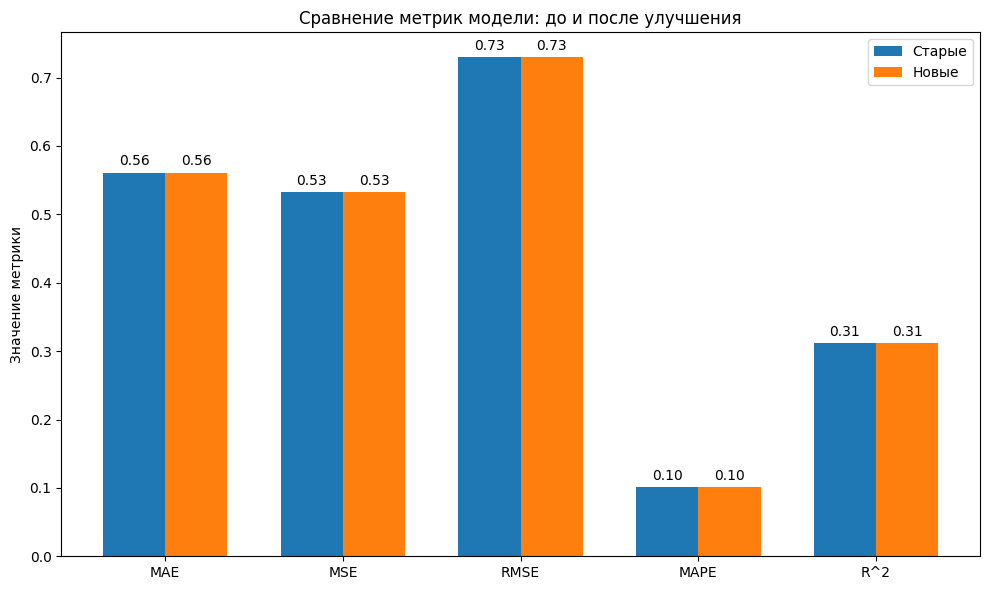

In [358]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_12104\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\andre\AppData\Local\Temp\ipykernel_12104\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns

<Axes: xlabel='quality', ylabel='Density'>

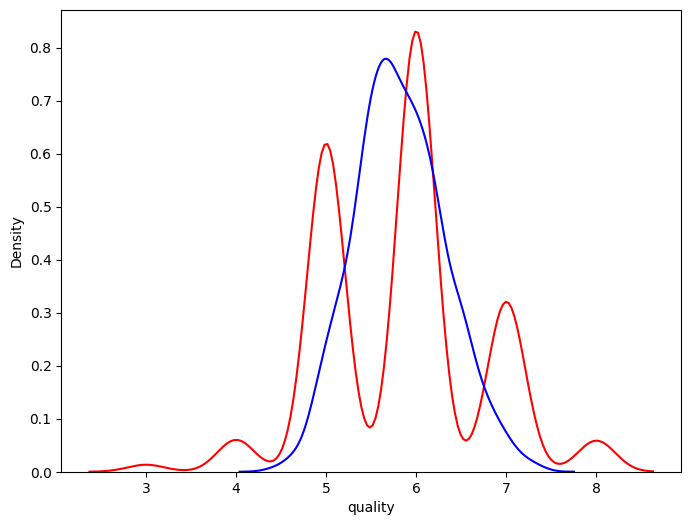

In [359]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Влияние предикторов на целевой признак

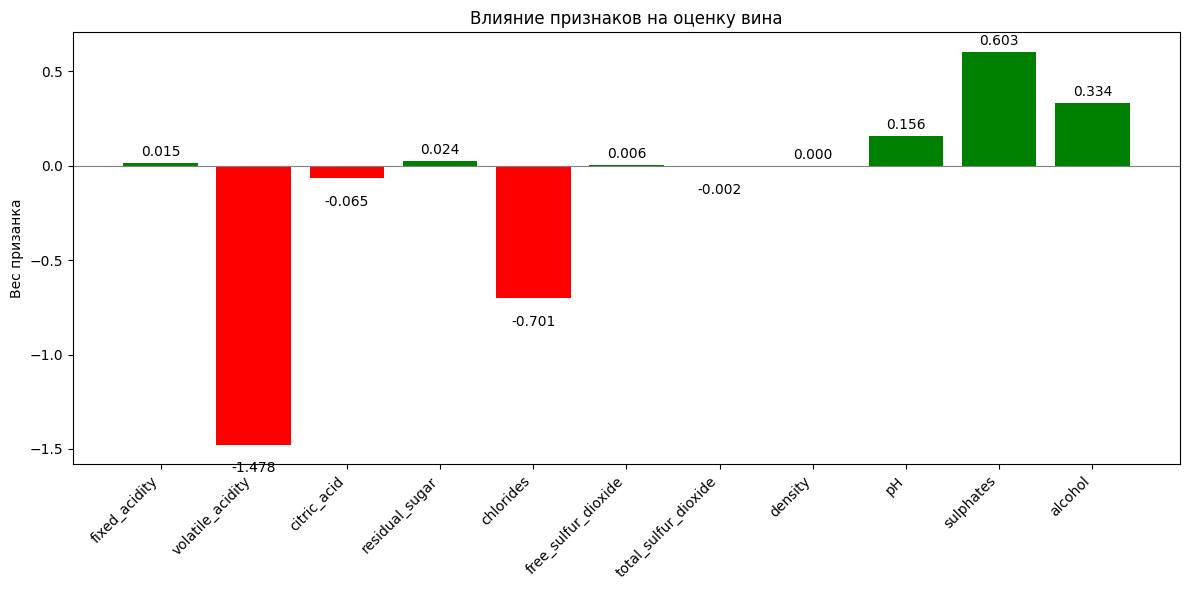

In [360]:
features = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar", "chlorides",
    "free_sulfur_dioxide", "total_sulfur_dioxide", "density", "pH", "sulphates", "alcohol"
]
weights = np.array([
    0.01527086, -1.47784147, -0.06488792, 0.02390045, -0.70087447,
    0.00559915, -0.0024541, -0.0, 0.15563081, 0.6031466, 0.33379409
])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(features, weights, color=np.where(weights >= 0, 'green', 'red'))

ax.set_title("Влияние признаков на оценку вина")
ax.set_ylabel("Вес призанка")
ax.axhline(0, color='gray', linewidth=0.8)

plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12), textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

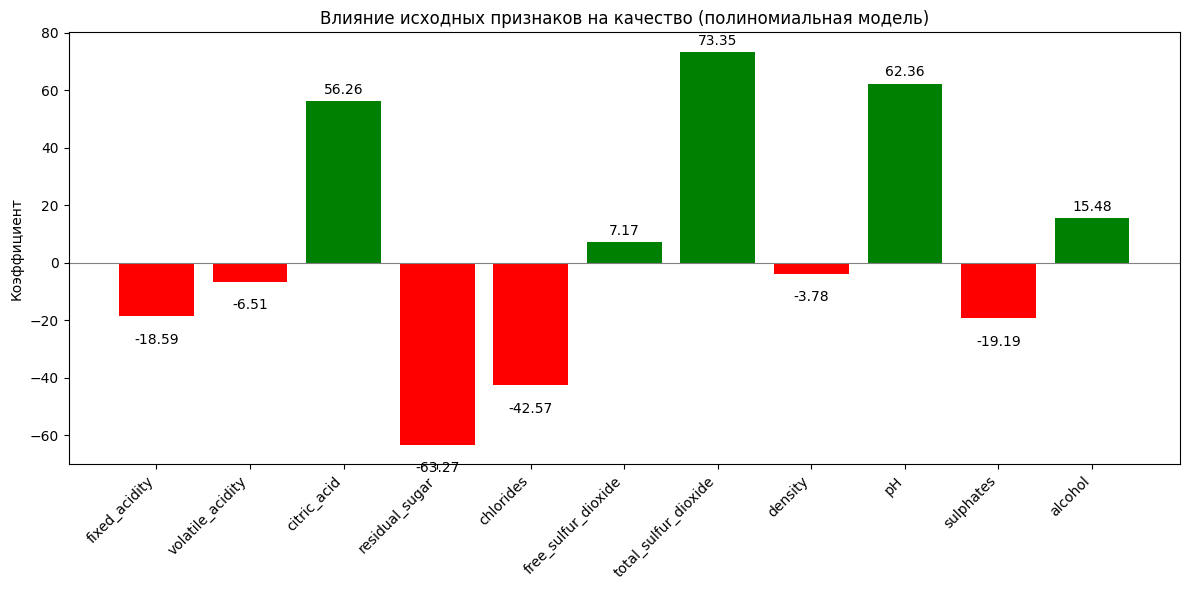

In [364]:
features = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar", "chlorides",
    "free_sulfur_dioxide", "total_sulfur_dioxide", "density", "pH", "sulphates", "alcohol"
]

n_features = len(features)

weights = np.array([-1.85872610e+01, -6.51061878e+00,  5.62617044e+01, -6.32742470e+01,
                    -4.25687169e+01,  7.17180908e+00,  7.33523247e+01, -3.78215024e+00,
                    6.23627112e+01, -1.91919956e+01,  1.54754279e+01, -7.40129989e-01,
                    3.85048246e-02,  7.74992453e-01, -4.67938896e-01, -5.82172570e-01,
                    1.68269680e-01,  7.44640829e-02,  1.81843802e+01,  1.27140205e+00,
                    3.28226767e-02, -1.07474030e-01,  4.95819450e-02,  3.09516850e-02,
                    -1.97433735e-01,  1.10833480e-01,  1.88947061e-03,  5.67360951e-02,
                    5.48993192e+00,  1.95469226e-01,  1.03050303e-02,  5.32963886e-01,
                    -1.27165738e-01,  2.37190568e-01,  1.35444306e-01,  1.05202074e-01,
                    9.96699254e-03, -5.78948058e+01,  1.16495859e+00, -7.63901658e-02,
                    -3.18351188e-01, -7.54121380e-01, -2.37121931e-01, -9.68459198e-02,
                    5.31126317e-01,  6.42458308e+01,  3.81053402e-02, -2.64698873e-01,
                    6.63358285e-01, -5.85874377e-02,  2.47083690e-02, -6.87006994e-02,
                    4.46325966e+01, -1.28320182e+00, -3.35305011e-01,  5.16687941e-02,
                    -1.18724818e-01, -1.11721136e-01, -8.08216883e+00,  3.99518250e-01,
                    1.58005614e-01,  3.89950552e-01,  2.92729018e-02, -7.32942521e+01,
                    7.86282178e-01, -3.34179228e-01, -9.96907233e-01,  7.60905378e+00,
                    -6.35093872e+01,  1.92856132e+01, -1.36851041e+01,  1.12485841e+00,
                    2.24706535e-01, -1.62166323e+00, -9.69779600e-02,  2.57193339e-01,
                    9.49497170e-02])

original_weights = weights[:n_features]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(features, original_weights, color=np.where(
    original_weights >= 0, 'green', 'red'))

ax.set_title("Влияние исходных признаков на качество (полиномиальная модель)")
ax.set_ylabel("Коэффициент")
ax.axhline(0, color='gray', linewidth=0.8)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12), textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

## Линейный регрессор

In [365]:
from sklearn.datasets import make_regression

In [368]:
class LinearRegressionL2:
    def __init__(self, learning_rate=0.01, n_iters=1000, alpha=0.1):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.alpha = alpha
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Градиентны
        for _ in range(self.n_iters):
            y_predicted = np.dot(X, self.weights) + self.bias
            error = y_predicted - y

            dw = (1 / n_samples) * \
                (np.dot(X.T, error) + self.alpha * self.weights)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


X, y = make_regression(n_samples=100, n_features=3, noise=10, random_state=42)

model = LinearRegressionL2(learning_rate=0.01, n_iters=1000, alpha=0.1)
model.fit(X, y)

predictions = model.predict(X)


def r2_score_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


r2 = r2_score_manual(y, predictions)
model.weights, model.bias, r2

(array([28.18640596, 73.90355783, 18.7496019 ]),
 np.float64(1.2658904972912581),
 np.float64(0.9854957348489706))